In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier



In [2]:
!git clone https://github.com/britmap-codes/cind-820-learning-analytics.git

Cloning into 'cind-820-learning-analytics'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 97 (delta 28), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 9.56 MiB | 13.09 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [3]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

processed_path = PROJECT_ROOT / "data" / "processed"
fig_path = PROJECT_ROOT / "reports" / "figures"
table_path = PROJECT_ROOT / "reports" / "tables"

fig_path.mkdir(parents=True, exist_ok=True)
table_path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data path:", processed_path)
print("Figures path:", fig_path)
print("Tables path:", table_path)

Project root: /content
Processed data path: /content/data/processed
Figures path: /content/reports/figures
Tables path: /content/reports/tables


In [5]:
from pathlib import Path

PROJECT_ROOT = Path("/content/cind-820-learning-analytics")

processed_path = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(processed_path / "oulad_student_level.csv")

In [6]:
df = pd.read_csv(processed_path / "oulad_student_level.csv")

if "at_risk" not in df.columns:
    df["at_risk"] = df["final_result"].map({
        "Fail": 1,
        "Withdrawn": 1,
        "Withdraw": 1,
        "Pass": 0,
        "Distinction": 0
    })

df = df.dropna(subset=["at_risk"]).copy()
df["at_risk"] = df["at_risk"].astype(int)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (32593, 16)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,mean_score,total_assessments,mean_weight,at_risk
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,20.0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,20.0,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,NaN,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,20.0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,20.0,0


In [7]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values by column:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("Target distribution:")
display(df["at_risk"].value_counts().rename_axis("at_risk").to_frame("count"))


Duplicate rows: 0
Missing values by column:


,missing_count
mean_score,6773
total_assessments,6750
mean_weight,6750
imd_band,1111
gender,0
code_module,0
id_student,0
code_presentation,0
age_band,0
highest_education,0


Target distribution:


,count
at_risk,
1,17208
0,15385


In [8]:
numeric_candidates = [
    "num_of_prev_attempts",
    "studied_credits",
    "mean_score",
    "total_assessments",
    "mean_weight"
]

numeric_cols = [column for column in numeric_candidates if column in df.columns]

numeric_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

descriptive_summary = pd.DataFrame({
    "count": numeric_df.count(),
    "mean": numeric_df.mean(),
    "median": numeric_df.median(),
    "mode": numeric_df.mode().iloc[0],
    "std": numeric_df.std(),
    "variance": numeric_df.var(),
    "min": numeric_df.min(),
    "max": numeric_df.max()
}).round(4)

display(descriptive_summary)

descriptive_summary.to_csv(
    table_path / "final_descriptive_statistics.csv"
)

,count,mean,median,mode,std,variance,min,max
num_of_prev_attempts,32593,0.1632,0.0,0.0000,0.4798,0.2302,0.0,6.0
studied_credits,32593,79.7587,60.0,60.0000,41.0719,1686.9010,30.0,655.0
mean_score,25820,72.7683,76.0,80.0000,16.3750,268.1405,0.0,100.0
total_assessments,25843,6.7296,7.0,12.0000,3.7714,14.2233,1.0,14.0
mean_weight,25843,13.3508,9.9,8.3333,8.8234,77.8527,0.0,100.0


In [9]:
categorical_candidates = [
    "code_module",
    "code_presentation",
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability"
]

categorical_cols = [
    column for column in categorical_candidates
    if column in df.columns
]

X = df[numeric_cols + categorical_cols]
y = df["at_risk"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)



Numeric features: ['num_of_prev_attempts', 'studied_credits', 'mean_score', 'total_assessments', 'mean_weight']
Categorical features: ['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']


In [10]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

models = {
    "Logistic Regression": log_reg_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline
}




In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 26074
Testing rows: 6519


In [12]:
results = []
fitted_models = {}

for model_name, pipeline in models.items():
    start = perf_counter()
    pipeline.fit(X_train, y_train)
    train_time = perf_counter() - start

    start = perf_counter()
    y_pred = pipeline.predict(X_test)
    prediction_time = perf_counter() - start

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Train_time_seconds": train_time,
        "Prediction_time_seconds": prediction_time
    })

    fitted_models[model_name] = pipeline

test_results = pd.DataFrame(results).round(4)

display(test_results)

test_results.to_csv(
    table_path / "final_test_and_efficiency_results.csv",
    index=False
)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Train_time_seconds,Prediction_time_seconds
0,Logistic Regression,0.9061,0.9405,0.8777,0.9080,0.9514,0.4593,0.0936
1,Decision Tree,0.9288,0.9797,0.8835,0.9291,0.9754,0.5638,0.1081
2,Random Forest,0.9356,0.9690,0.9070,0.9370,0.9786,36.5098,0.2436


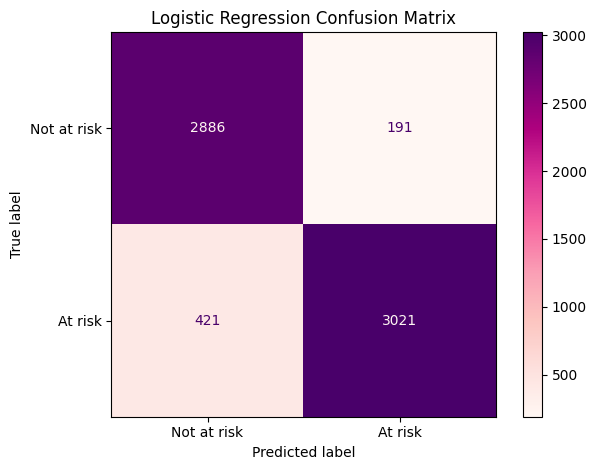

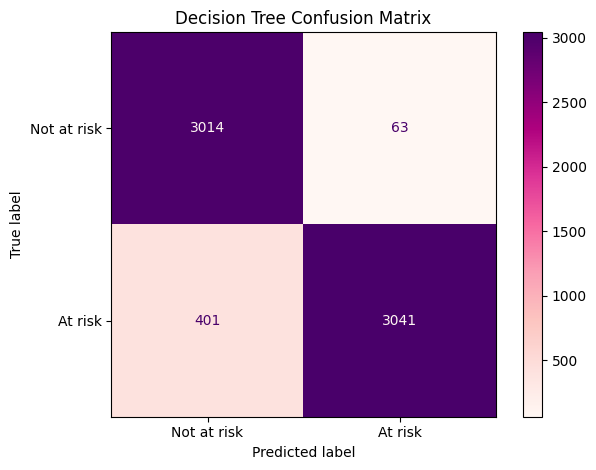

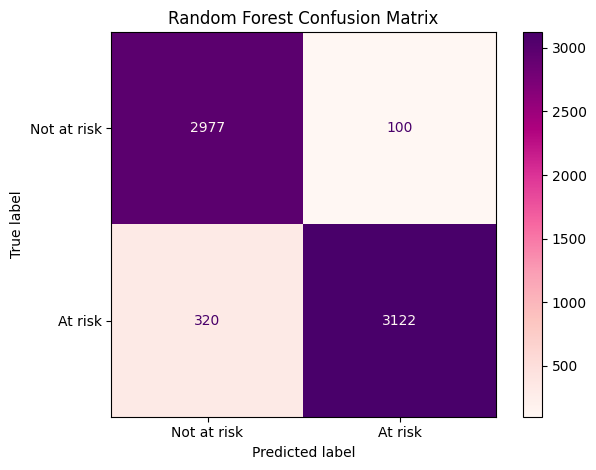

In [25]:
for model_name, pipeline in fitted_models.items():
    y_pred = pipeline.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Not at risk", "At risk"],
        cmap="RdPu"
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()

    file_name = model_name.lower().replace(" ", "_")

    plt.savefig(
        fig_path / f"{file_name}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

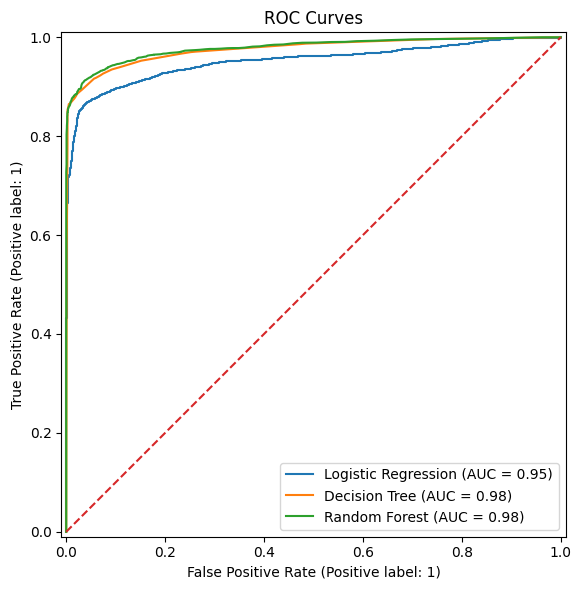

In [14]:
plt.figure(figsize=(7, 6))

for model_name, pipeline in fitted_models.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=model_name,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves")
plt.tight_layout()

plt.savefig(
    fig_path / "combined_roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [17]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_rows = []
fold_rows = []

for model_name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_rows.append({
        "Model": model_name,
        "Mean_Accuracy": scores["test_accuracy"].mean(),
        "SD_Accuracy": scores["test_accuracy"].std(),
        "Mean_Precision": scores["test_precision"].mean(),
        "SD_Precision": scores["test_precision"].std(),
        "Mean_Recall": scores["test_recall"].mean(),
        "SD_Recall": scores["test_recall"].std(),
        "Mean_F1": scores["test_f1"].mean(),
        "SD_F1": scores["test_f1"].std(),
        "Mean_ROC_AUC": scores["test_roc_auc"].mean(),
        "SD_ROC_AUC": scores["test_roc_auc"].std()
    })

    for fold_number in range(5):
        fold_rows.append({
            "Model": model_name,
            "Fold": fold_number + 1,
            "Accuracy": scores["test_accuracy"][fold_number],
            "Precision": scores["test_precision"][fold_number],
            "Recall": scores["test_recall"][fold_number],
            "F1": scores["test_f1"][fold_number],
            "ROC_AUC": scores["test_roc_auc"][fold_number]
        })

cv_results = pd.DataFrame(cv_rows).round(4)
fold_results = pd.DataFrame(fold_rows).round(4)

display(cv_results)
display(fold_results)

cv_results.to_csv(
    table_path / "final_cv_results.csv",
    index=False
)

fold_results.to_csv(
    table_path / "final_fold_scores.csv",
    index=False
)


,Model,Mean_Accuracy,SD_Accuracy,Mean_Precision,SD_Precision,Mean_Recall,SD_Recall,Mean_F1,SD_F1,Mean_ROC_AUC,SD_ROC_AUC
0,Logistic Regression,0.9093,0.0012,0.9402,0.0033,0.8845,0.0044,0.9115,0.0014,0.9530,0.0017
1,Decision Tree,0.9318,0.0038,0.9765,0.0025,0.8923,0.0079,0.9325,0.0040,0.9747,0.0006
2,Random Forest,0.9365,0.0042,0.9678,0.0038,0.9099,0.0050,0.9380,0.0041,0.9788,0.0007


,Model,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,1,0.9096,0.9459,0.8791,0.9113,0.9527
1,Logistic Regression,2,0.9095,0.9415,0.8835,0.9116,0.9511
2,Logistic Regression,3,0.9081,0.9378,0.8847,0.9104,0.9528
3,Logistic Regression,4,0.9113,0.9366,0.8925,0.9140,0.9561
4,Logistic Regression,5,0.9079,0.9391,0.8829,0.9101,0.9525
5,Decision Tree,1,0.9302,0.9749,0.8908,0.9309,0.9739
6,Decision Tree,2,0.9308,0.9770,0.8899,0.9314,0.9750
7,Decision Tree,3,0.9334,0.9811,0.8911,0.9339,0.9748
8,Decision Tree,4,0.9380,0.9738,0.9070,0.9392,0.9743
9,Decision Tree,5,0.9267,0.9759,0.8829,0.9271,0.9755


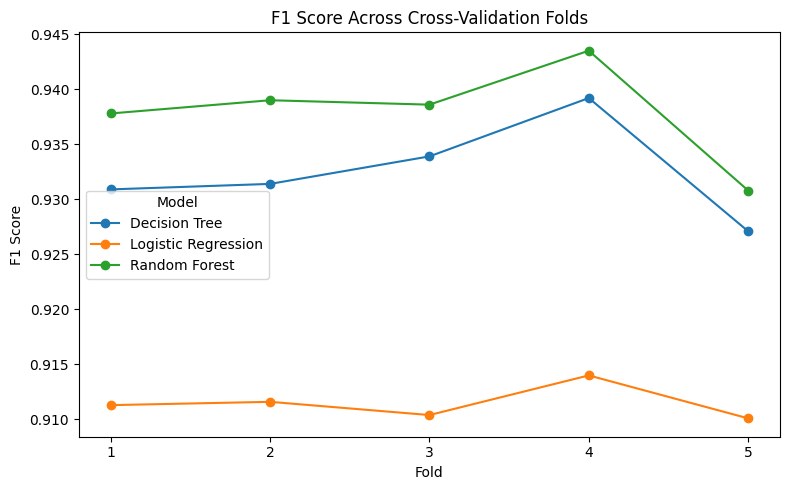

In [18]:
fold_plot = fold_results.pivot(
    index="Fold",
    columns="Model",
    values="F1"
)

fold_plot.plot(
    marker="o",
    figsize=(8, 5)
)

plt.title("F1 Score Across Cross-Validation Folds")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.xticks(fold_plot.index)
plt.tight_layout()

plt.savefig(
    fig_path / "cv_f1_by_fold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [19]:
rf_f1 = (
    fold_results[
        fold_results["Model"] == "Random Forest"
    ]
    .sort_values("Fold")["F1"]
    .to_numpy()
)

log_f1 = (
    fold_results[
        fold_results["Model"] == "Logistic Regression"
    ]
    .sort_values("Fold")["F1"]
    .to_numpy()
)

tree_f1 = (
    fold_results[
        fold_results["Model"] == "Decision Tree"
    ]
    .sort_values("Fold")["F1"]
    .to_numpy()
)

rf_vs_log_stat, rf_vs_log_p = wilcoxon(rf_f1, log_f1)
rf_vs_tree_stat, rf_vs_tree_p = wilcoxon(rf_f1, tree_f1)

statistical_results = pd.DataFrame([
    {
        "Comparison": "Random Forest vs Logistic Regression",
        "Metric": "F1",
        "Statistic": rf_vs_log_stat,
        "P_value": rf_vs_log_p,
        "Mean_difference": (rf_f1 - log_f1).mean()
    },
    {
        "Comparison": "Random Forest vs Decision Tree",
        "Metric": "F1",
        "Statistic": rf_vs_tree_stat,
        "P_value": rf_vs_tree_p,
        "Mean_difference": (rf_f1 - tree_f1).mean()
    }
]).round(5)

display(statistical_results)

statistical_results.to_csv(
    table_path / "final_statistical_comparisons.csv",
    index=False
)



,Comparison,Metric,Statistic,P_value,Mean_difference
0,Random Forest vs Logistic Regression,F1,0.0,0.0625,0.02646
1,Random Forest vs Decision Tree,F1,0.0,0.0625,0.00544


,Feature,Importance
3,numeric__total_assessments,0.310713
4,numeric__mean_weight,0.259790
2,numeric__mean_score,0.198455
1,numeric__studied_credits,0.019459
10,categorical__code_module_FFF,0.013846
8,categorical__code_module_DDD,0.008271
33,categorical__highest_education_Lower Than A Level,0.008043
15,categorical__code_presentation_2014J,0.007925
0,numeric__num_of_prev_attempts,0.007779
12,categorical__code_presentation_2013B,0.007646


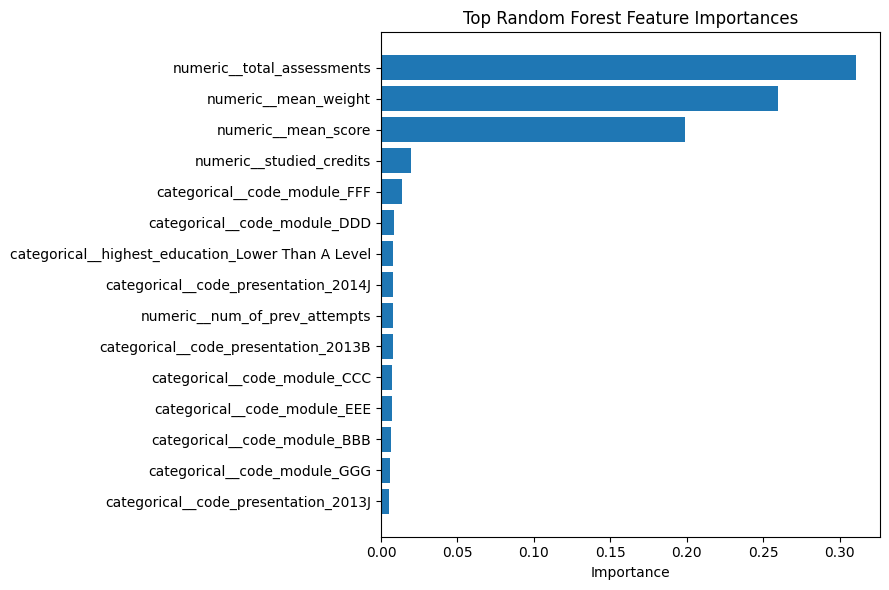

In [20]:
rf_fitted = fitted_models["Random Forest"]

feature_names = (
    rf_fitted
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_values = (
    rf_fitted
    .named_steps["model"]
    .feature_importances_
)

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": feature_values
    })
    .sort_values("Importance", ascending=False)
)

display(feature_importance.head(15))

feature_importance.to_csv(
    table_path / "final_random_forest_feature_importance.csv",
    index=False
)

top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()

plt.savefig(
    fig_path / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
permutation = permutation_importance(
    rf_fitted,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_results = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Mean_importance": permutation.importances_mean,
        "SD_importance": permutation.importances_std
    })
    .sort_values("Mean_importance", ascending=False)
)

display(permutation_results)

permutation_results.to_csv(
    table_path / "final_permutation_importance.csv",
    index=False
)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Feature,Mean_importance,SD_importance
3,total_assessments,0.226191,0.005213
4,mean_weight,0.154125,0.004652
2,mean_score,0.041162,0.001840
5,code_module,0.032044,0.002560
6,code_presentation,0.001996,0.000815
7,gender,0.001933,0.000531
8,region,0.001799,0.000566
11,age_band,0.001642,0.000736
1,studied_credits,0.001578,0.000524
10,imd_band,0.001524,0.000720


In [22]:
final_model_comparison = (
    test_results
    .merge(
        cv_results,
        on="Model",
        how="left"
    )
    .sort_values(
        ["F1", "Recall"],
        ascending=False
    )
)

display(final_model_comparison)

final_model_comparison.to_csv(
    table_path / "final_model_comparison.csv",
    index=False
)

print("Tables saved to:", table_path)
print("Figures saved to:", fig_path)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Train_time_seconds,Prediction_time_seconds,Mean_Accuracy,SD_Accuracy,Mean_Precision,SD_Precision,Mean_Recall,SD_Recall,Mean_F1,SD_F1,Mean_ROC_AUC,SD_ROC_AUC
2,Random Forest,0.9356,0.9690,0.9070,0.9370,0.9786,36.5098,0.2436,0.9365,0.0042,0.9678,0.0038,0.9099,0.0050,0.9380,0.0041,0.9788,0.0007
1,Decision Tree,0.9288,0.9797,0.8835,0.9291,0.9754,0.5638,0.1081,0.9318,0.0038,0.9765,0.0025,0.8923,0.0079,0.9325,0.0040,0.9747,0.0006
0,Logistic Regression,0.9061,0.9405,0.8777,0.9080,0.9514,0.4593,0.0936,0.9093,0.0012,0.9402,0.0033,0.8845,0.0044,0.9115,0.0014,0.9530,0.0017


Tables saved to: /content/reports/tables
Figures saved to: /content/reports/figures
